Imports and Data Loading

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)

csv_path = '../results/hybrid_benchmark_results.csv'
df = pd.read_csv(csv_path)

baselines = [
    {
        'dataset': 'data/sift_base.fvecs', 'M': 16, 'ef_construction': 200, 
        'batch_size': 'Baseline', 'candidates_per_query': 'Baseline', 
        'beam_search_ef': 'Baseline', 'seed_size': 'Baseline',
        'build_time_sec': 86.5564,     
        'throughput_vec_sec': 11553.2,  
        'recall_1': 0.9924,         
        'recall_10': 0.983099,          
        'links_to_seed': np.nan, 
        'links_to_hybrid': np.nan, 
        'isolated_nodes': 0,        
        'starved_nodes': 0,        
        'avg_out_degree': 21.2352,     
        'type': 'Pure CPU Baseline'
    },
    {
        'dataset': 'data/synthetic_768d_base.fvecs', 'M': 16, 'ef_construction': 200, 
        'batch_size': 'Baseline', 'candidates_per_query': 'Baseline', 
        'beam_search_ef': 'Baseline', 'seed_size': 'Baseline',
        'build_time_sec': 778.148,     
        'throughput_vec_sec': 1285.1,  
        'recall_1': 0.0936,         
        'recall_10': 0.0746591,      
        'links_to_seed': np.nan, 
        'links_to_hybrid': np.nan, 
        'isolated_nodes': 0,       
        'starved_nodes': 0,      
        'avg_out_degree': 19.1812,     
        'type': 'Pure CPU Baseline'
    }
]

df['type'] = 'Hybrid CPU-GPU'
df = pd.concat([df, pd.DataFrame(baselines)], ignore_index=True)

df['dataset_clean'] = df['dataset'].apply(lambda x: 'SIFT (128D)' if 'sift' in x else 'Synthetic (768D)')

print("Data loaded successfully! Total runs:", len(df))

Data loaded successfully! Total runs: 110


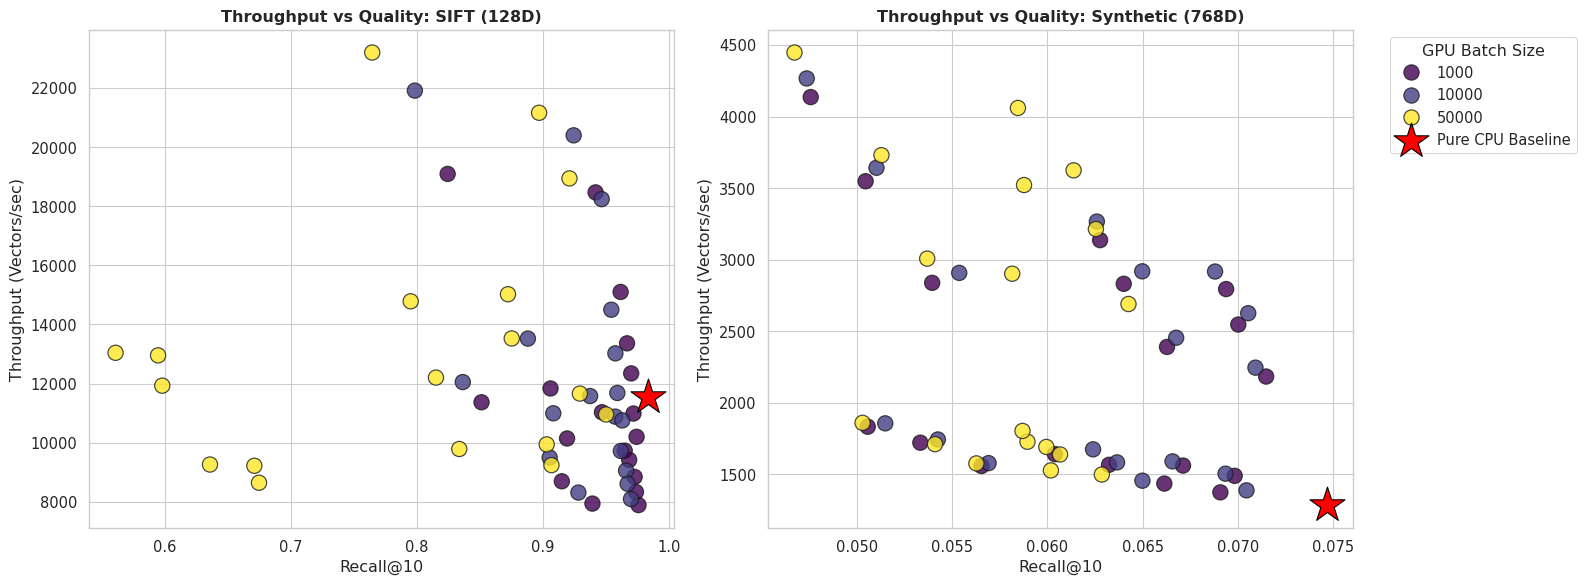

In [3]:
# --- PLOT 1: DIMENSIONALITY PARETO FRONTIER ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
datasets = ['SIFT (128D)', 'Synthetic (768D)']

for i, ds_name in enumerate(datasets):
    ax = axes[i]
    subset = df[df['dataset_clean'] == ds_name]
    
    # Plot Hybrid Runs
    hybrid_subset = subset[subset['type'] == 'Hybrid CPU-GPU']
    sns.scatterplot(
        data=hybrid_subset, x='recall_10', y='throughput_vec_sec', 
        hue='batch_size', palette='viridis', s=120, ax=ax, alpha=0.8, edgecolor='k'
    )
    
    # Plot CPU Baseline
    baseline_subset = subset[subset['type'] == 'Pure CPU Baseline']
    ax.scatter(
        baseline_subset['recall_10'], baseline_subset['throughput_vec_sec'], 
        color='red', marker='*', s=700, label='Pure CPU Baseline', edgecolor='black', zorder=5
    )
    
    ax.set_title(f'Throughput vs Quality: {ds_name}', fontweight='bold')
    ax.set_xlabel('Recall@10')
    ax.set_ylabel('Throughput (Vectors/sec)')
    
    if i == 1:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="GPU Batch Size")
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.savefig('pareto_frontier.png')
plt.show()

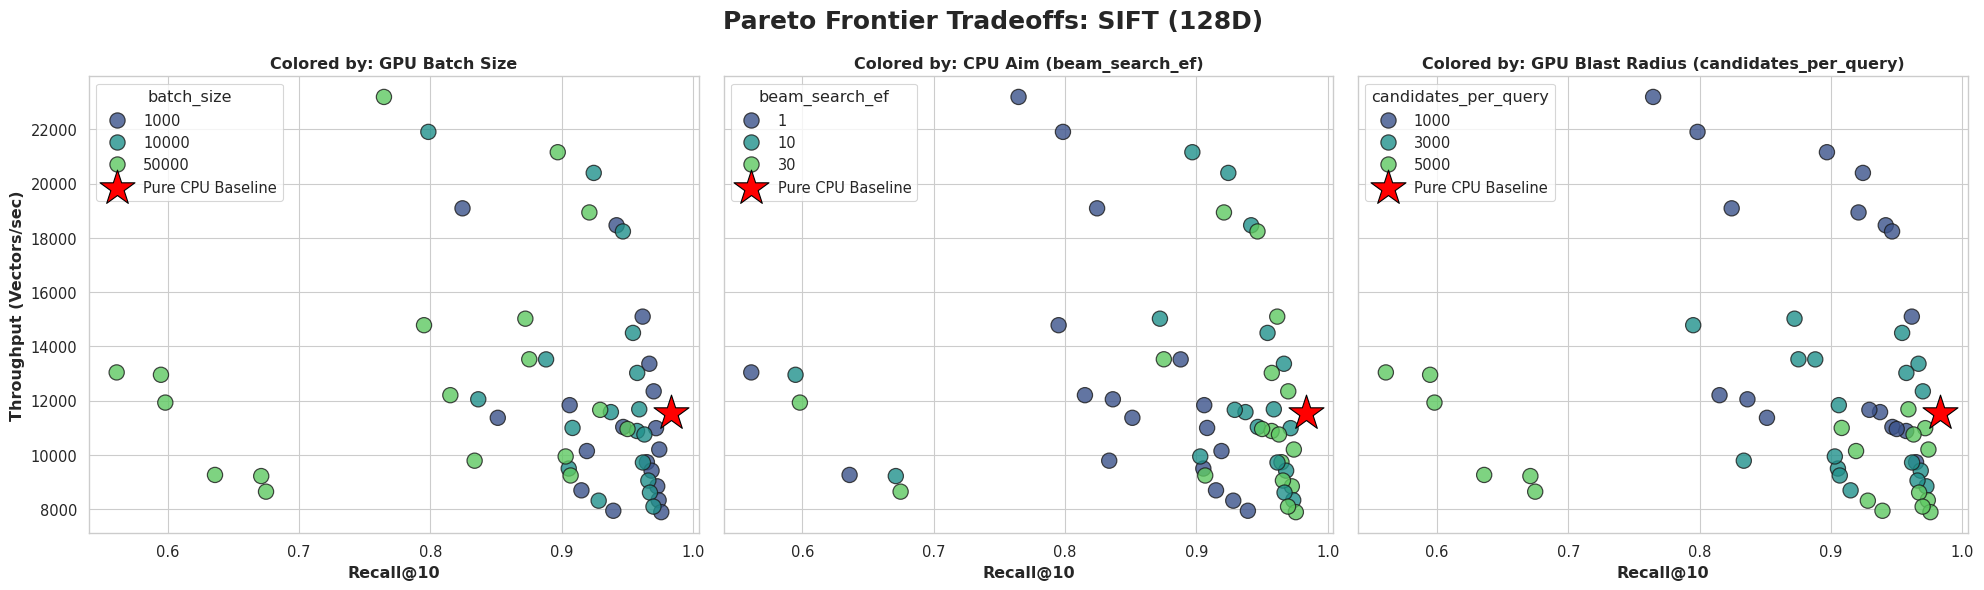

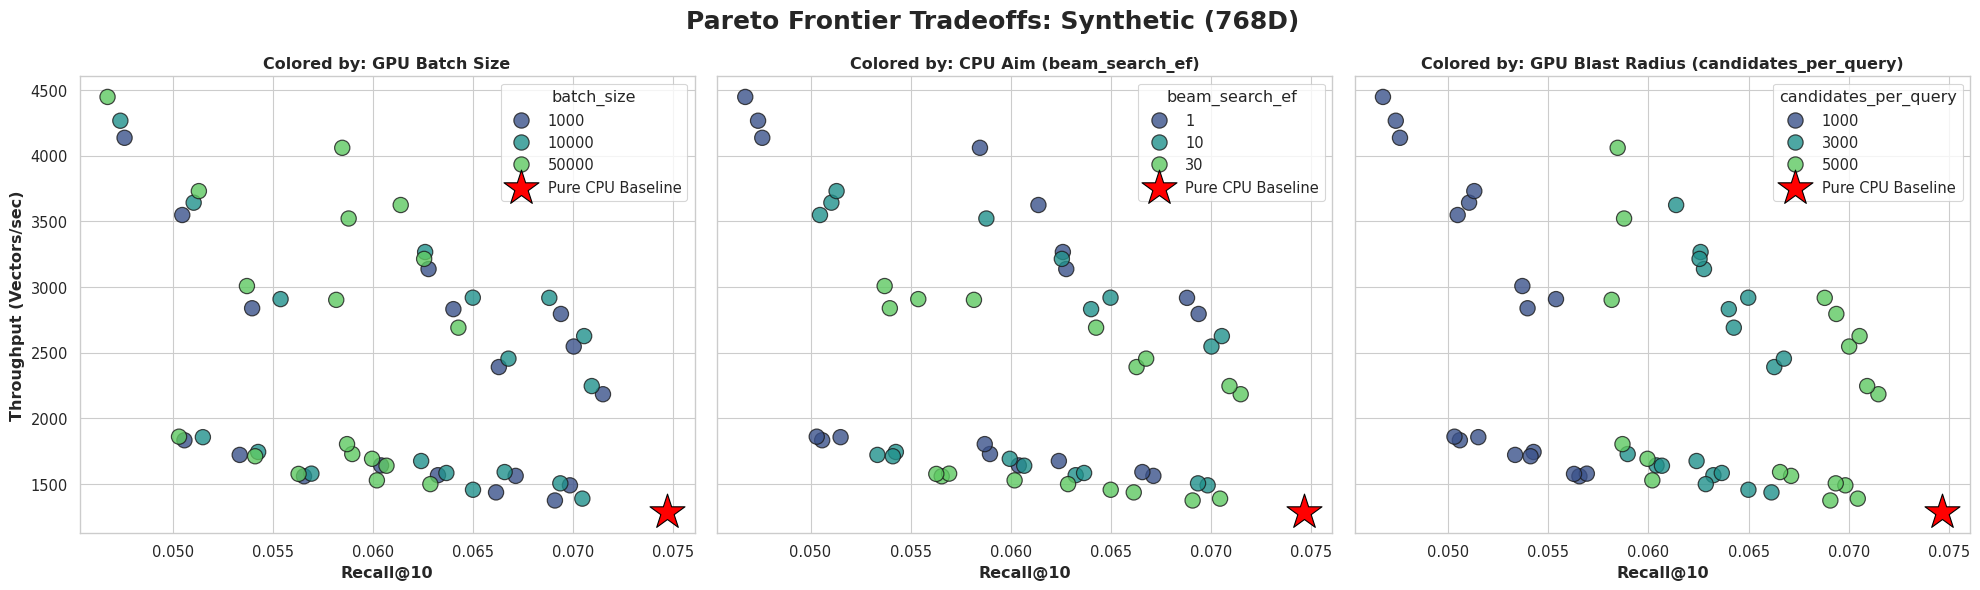

In [16]:
# --- PARETO FRONTIER BREAKDOWN (BY PARAMETER) ---
# This generates two figures (one for SIFT, one for 768D).
# Each figure has 3 panels showing the same points, colored by different parameters.

parameters = ['batch_size', 'beam_search_ef', 'candidates_per_query']
titles = ['GPU Batch Size', 'CPU Aim (beam_search_ef)', 'GPU Blast Radius (candidates_per_query)']
datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds_name in datasets:
    # Isolate the dataset
    subset = df[df['dataset_clean'] == ds_name]
    hybrid_subset = subset[subset['type'] == 'Hybrid CPU-GPU'].copy()
    baseline_subset = subset[subset['type'] == 'Pure CPU Baseline']
    
    # Ensure parameters are treated as categorical for distinct coloring
    for param in parameters:
        hybrid_subset[param] = pd.Categorical(hybrid_subset[param], ordered=True)
        
    # Create a 1x3 grid for the three parameters
    fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True, sharey=True)
    
    for i, param in enumerate(parameters):
        ax = axes[i]
        
        # Plot Hybrid Runs
        sns.scatterplot(
            data=hybrid_subset, x='recall_10', y='throughput_vec_sec', 
            hue=param, palette='viridis', s=120, ax=ax, alpha=0.8, edgecolor='k'
        )
        
        # Plot Pure CPU Baseline
        if not baseline_subset.empty:
            ax.scatter(
                baseline_subset['recall_10'], baseline_subset['throughput_vec_sec'], 
                color='red', marker='*', s=700, label='Pure CPU Baseline', edgecolor='black', zorder=5
            )
            
        ax.set_title(f'Colored by: {titles[i]}', fontweight='bold')
        ax.set_xlabel('Recall@10', fontweight='bold')
        
        if i == 0:
            ax.set_ylabel('Throughput (Vectors/sec)', fontweight='bold')
        else:
            ax.set_ylabel('') # Hide Y-labels on middle and right plots for cleanliness
            
        # Clean up legends
        handles, labels = ax.get_legend_handles_labels()
        # Ensure the Red Star baseline is included in the legend
        ax.legend(handles=handles, title=param, loc='best')

    plt.suptitle(f'Pareto Frontier Tradeoffs: {ds_name}', fontweight='bold', fontsize=18)
    plt.tight_layout()
    
    # Save cleanly for LaTeX
    clean_name = ds_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f'pareto_breakdown_{clean_name}.png', dpi=300)
    plt.show()

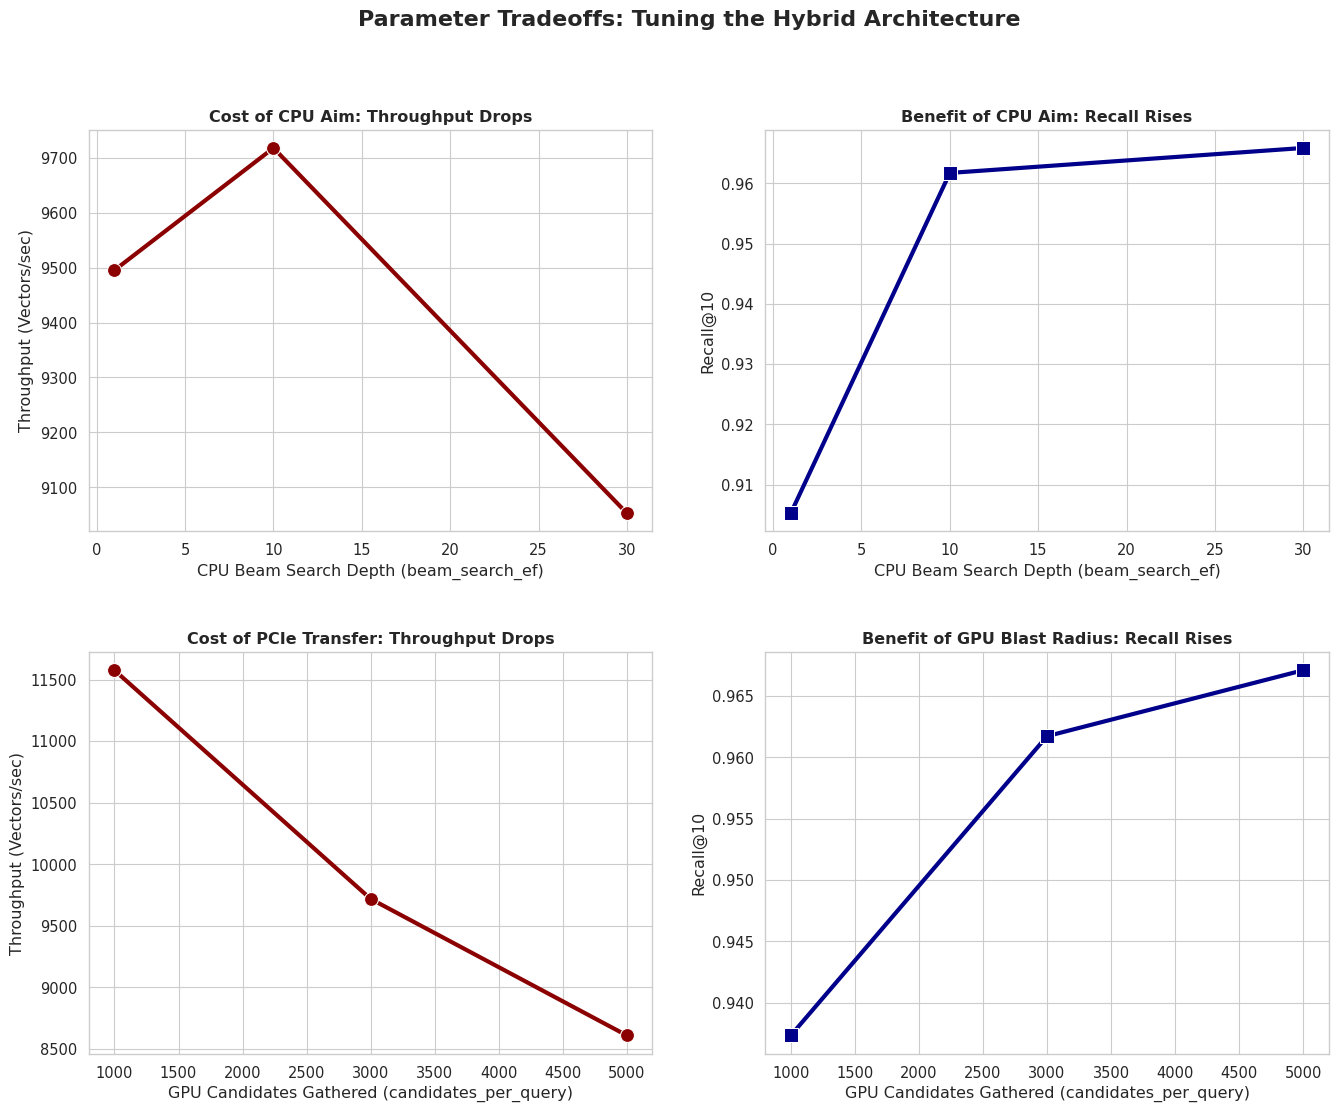

In [11]:
# --- PARAMETER TRADEOFFS: SPEED VS QUALITY ---
# Isolate SIFT runs with a seed graph and a locked batch size (10,000) to remove noise
tradeoff_df = df[(df['dataset_clean'] == 'SIFT (128D)') & 
                 (df['type'] == 'Hybrid CPU-GPU') & 
                 (df['batch_size'] == 10000) & 
                 (df['seed_size'] == 200000)].copy()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# --- ROW 1: The CPU Aim (beam_search_ef) ---
# Lock candidates_per_query to 3000 to isolate the CPU parameter
beam_df = tradeoff_df[tradeoff_df['candidates_per_query'] == 3000].sort_values('beam_search_ef')

sns.lineplot(data=beam_df, x='beam_search_ef', y='throughput_vec_sec', marker='o', markersize=10, linewidth=3, color='darkred', ax=axes[0, 0])
axes[0, 0].set_title('Cost of CPU Aim: Throughput Drops', fontweight='bold')
axes[0, 0].set_xlabel('CPU Beam Search Depth (beam_search_ef)')
axes[0, 0].set_ylabel('Throughput (Vectors/sec)')

sns.lineplot(data=beam_df, x='beam_search_ef', y='recall_10', marker='s', markersize=10, linewidth=3, color='darkblue', ax=axes[0, 1])
axes[0, 1].set_title('Benefit of CPU Aim: Recall Rises', fontweight='bold')
axes[0, 1].set_xlabel('CPU Beam Search Depth (beam_search_ef)')
axes[0, 1].set_ylabel('Recall@10')

# --- ROW 2: The GPU Blast Radius (candidates_per_query) ---
# Lock beam_search_ef to 10 to isolate the GPU parameter
cand_df = tradeoff_df[tradeoff_df['beam_search_ef'] == 10].sort_values('candidates_per_query')

sns.lineplot(data=cand_df, x='candidates_per_query', y='throughput_vec_sec', marker='o', markersize=10, linewidth=3, color='darkred', ax=axes[1, 0])
axes[1, 0].set_title('Cost of PCIe Transfer: Throughput Drops', fontweight='bold')
axes[1, 0].set_xlabel('GPU Candidates Gathered (candidates_per_query)')
axes[1, 0].set_ylabel('Throughput (Vectors/sec)')

sns.lineplot(data=cand_df, x='candidates_per_query', y='recall_10', marker='s', markersize=10, linewidth=3, color='darkblue', ax=axes[1, 1])
axes[1, 1].set_title('Benefit of GPU Blast Radius: Recall Rises', fontweight='bold')
axes[1, 1].set_xlabel('GPU Candidates Gathered (candidates_per_query)')
axes[1, 1].set_ylabel('Recall@10')

plt.suptitle('Parameter Tradeoffs: Tuning the Hybrid Architecture', fontweight='bold', fontsize=16)
plt.savefig('parameter_tradeoffs.png', dpi=300, bbox_inches='tight')
plt.show()

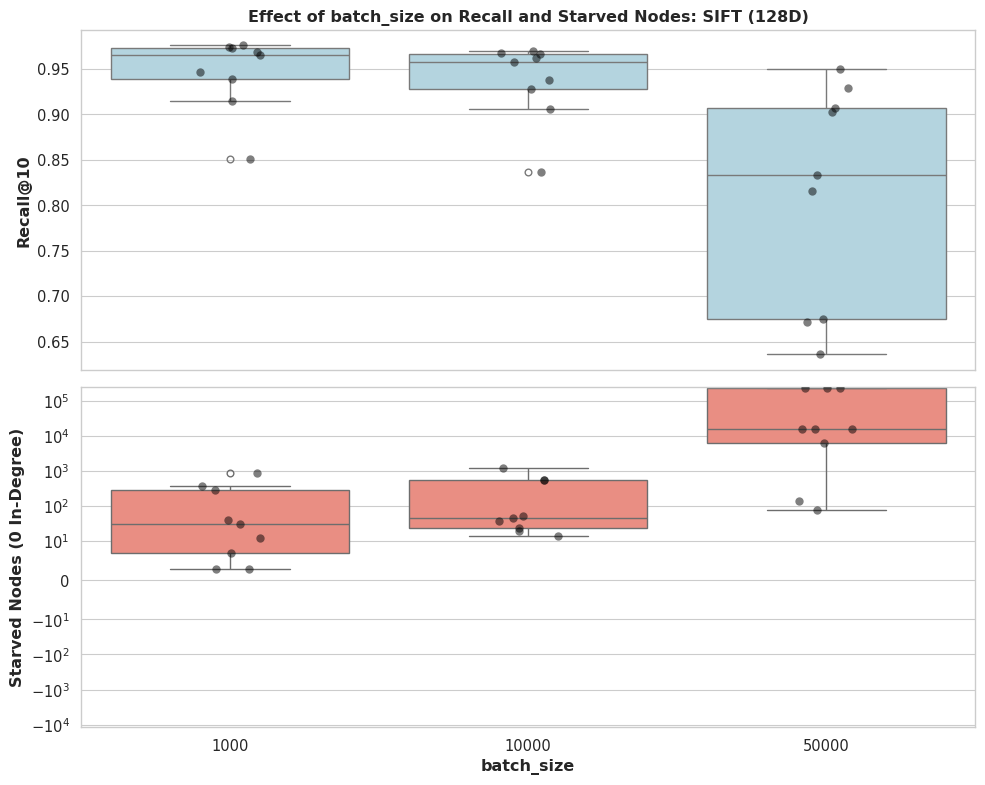

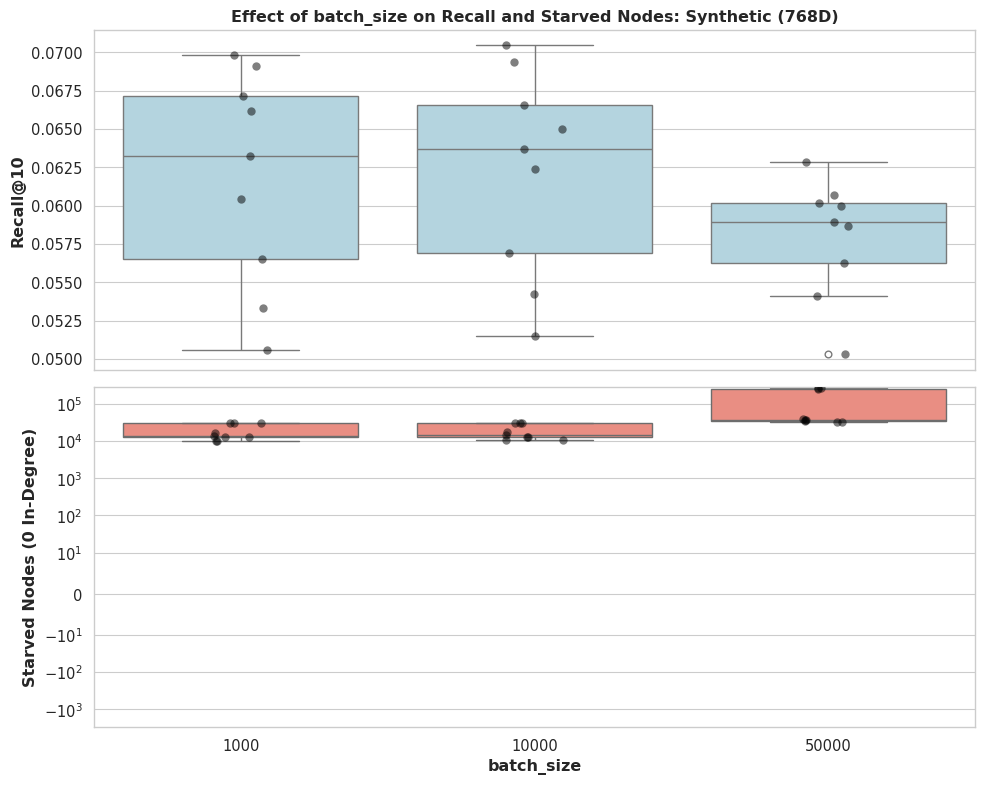

In [14]:
# --- REVISED PLOT 2: BATCH SIZE VS TOPOLOGY (BOXPLOTS) ---
# Filter for hybrid runs with a standard seed graph
batch_df = df[(df['type'] == 'Hybrid CPU-GPU') & (df['seed_size'] == 200000)].copy()

# Ensure batch_size is treated as a sorted categorical variable
batch_df['batch_size'] = pd.Categorical(batch_df['batch_size'], categories=[1000, 10000, 50000], ordered=True)

datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds_name in datasets:
    sub_df = batch_df[batch_df['dataset_clean'] == ds_name]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Top Plot: Recall Boxplots
    sns.boxplot(data=sub_df, x='batch_size', y='recall_10', color='lightblue', ax=ax1)
    sns.stripplot(data=sub_df, x='batch_size', y='recall_10', color='black', alpha=0.5, size=6, ax=ax1)
    ax1.set_ylabel('Recall@10', fontweight='bold')
    ax1.set_title(f'Effect of batch_size on Recall and Starved Nodes: {ds_name}', fontweight='bold')
    
    # Bottom Plot: Starved Nodes Boxplots (using symlog to handle extreme variance and zeros)
    sns.boxplot(data=sub_df, x='batch_size', y='starved_nodes', color='salmon', ax=ax2)
    sns.stripplot(data=sub_df, x='batch_size', y='starved_nodes', color='black', alpha=0.5, size=6, ax=ax2)
    ax2.set_ylabel('Starved Nodes (0 In-Degree)', fontweight='bold')
    ax2.set_xlabel('batch_size', fontweight='bold')
    
    # symlog allows the graph to show values near 0 normally, but compress large spikes logarithmically
    ax2.set_yscale('symlog', linthresh=10) 
    
    plt.tight_layout()
    clean_name = ds_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.savefig(f'batch_topology_{clean_name}.png', dpi=300)
    plt.show()

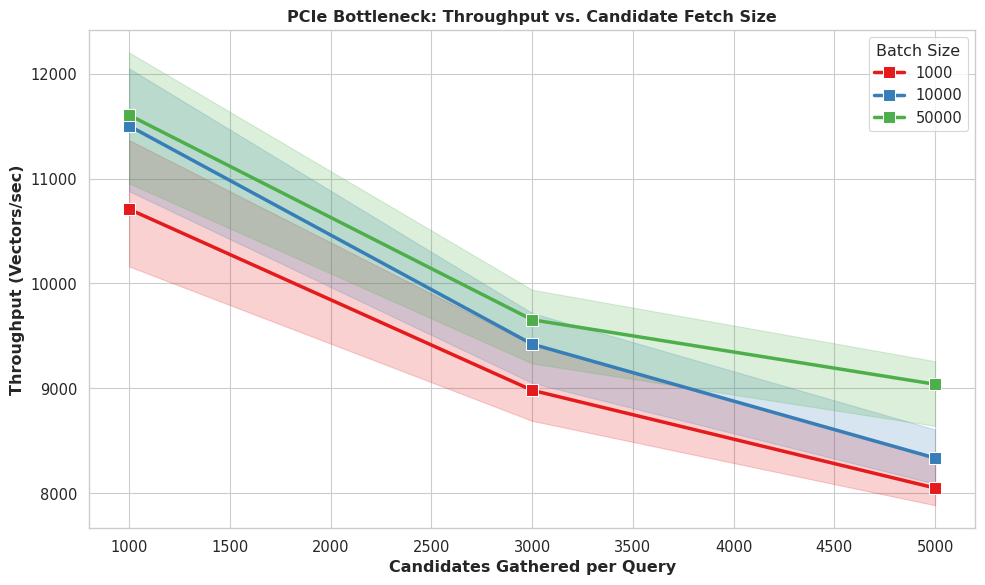

In [8]:
# --- REDESIGNED PLOT 3: PCIe TRANSFER BOTTLENECK ---
# Filter for SIFT, with seed, to look purely at candidate transfer speeds
cand_df = df[(df['dataset_clean'] == 'SIFT (128D)') & 
             (df['type'] == 'Hybrid CPU-GPU') & 
             (df['seed_size'] == 200000)].copy()

cand_df['candidates_per_query'] = pd.to_numeric(cand_df['candidates_per_query'])
cand_df['batch_size'] = pd.Categorical(cand_df['batch_size'])

fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=cand_df, x='candidates_per_query', y='throughput_vec_sec', 
    hue='batch_size', marker='s', linewidth=2.5, markersize=8, palette='Set1', ax=ax
)

ax.set_title('PCIe Bottleneck: Throughput vs. Candidate Fetch Size', fontweight='bold')
ax.set_xlabel('Candidates Gathered per Query', fontweight='bold')
ax.set_ylabel('Throughput (Vectors/sec)', fontweight='bold')
ax.legend(title='Batch Size', loc='upper right')

plt.tight_layout()
plt.savefig('pcie_bottleneck_clean.png')
plt.show()

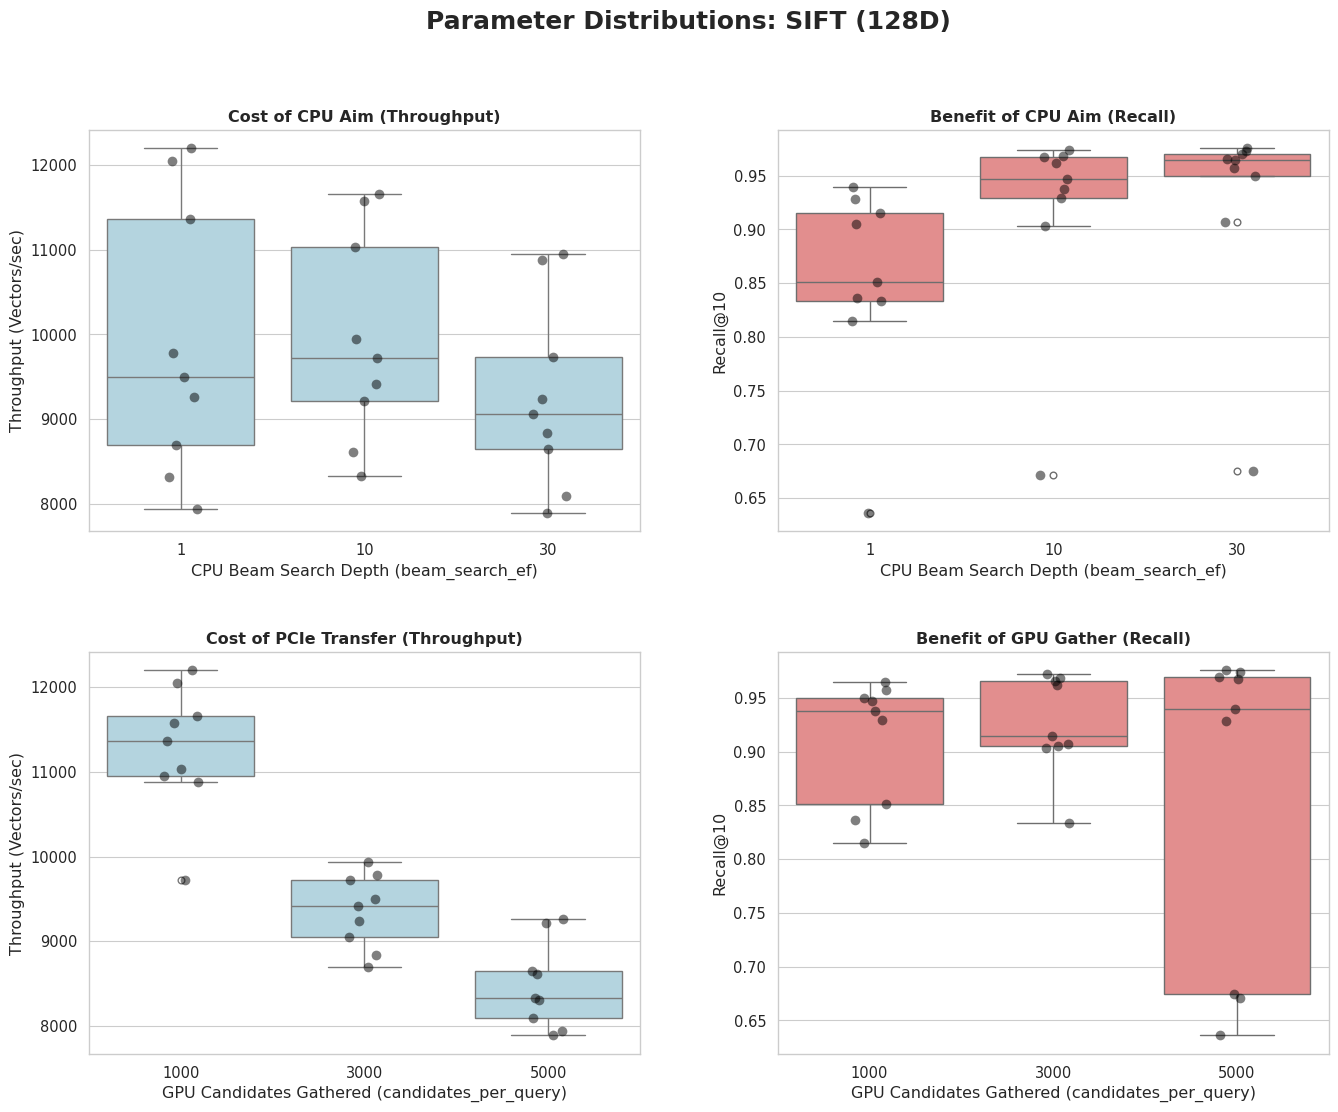

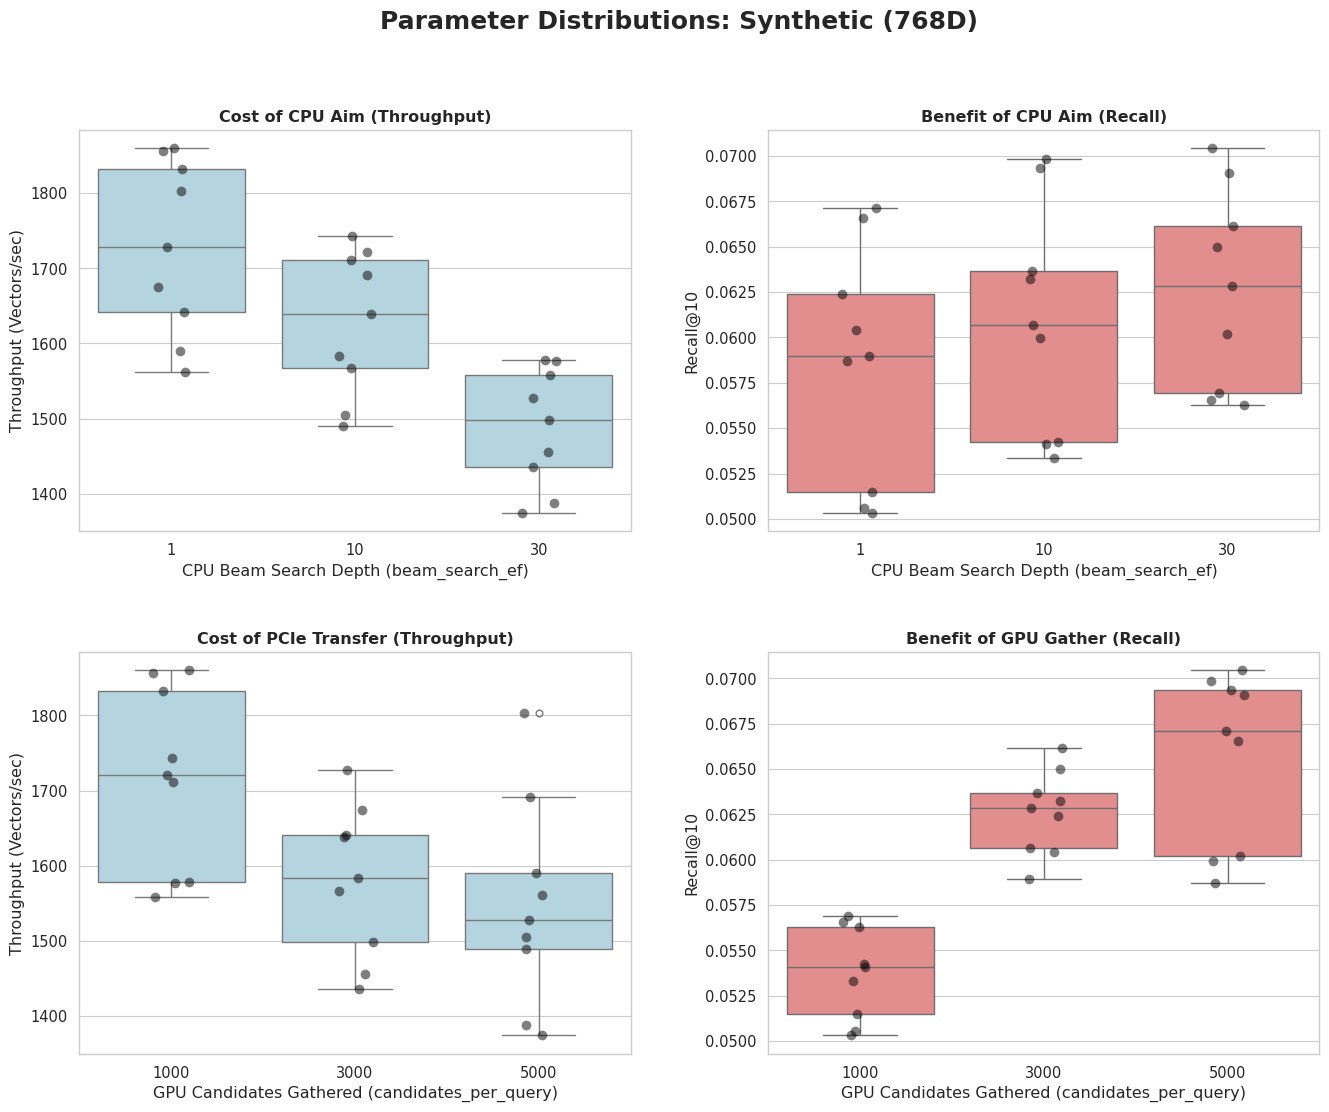

In [12]:
# --- PARAMETER DISTRIBUTIONS: SIFT vs 768D ---
# We filter out seed_size=0 because we already proved it's unviable. 
# We want to see how the parameters behave on the stable architecture.
dist_df = df[(df['type'] == 'Hybrid CPU-GPU') & (df['seed_size'] == 200000)].copy()

datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds_name in datasets:
    # Isolate the specific dataset
    sub_df = dist_df[dist_df['dataset_clean'] == ds_name]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.25)
    
    # ---------------------------------------------------------
    # ROW 1: CPU AIM (beam_search_ef)
    # ---------------------------------------------------------
    # Speed Cost
    sns.boxplot(data=sub_df, x='beam_search_ef', y='throughput_vec_sec', color='lightblue', ax=axes[0, 0])
    sns.stripplot(data=sub_df, x='beam_search_ef', y='throughput_vec_sec', color='black', alpha=0.5, size=7, ax=axes[0, 0])
    axes[0, 0].set_title(f'Cost of CPU Aim (Throughput)', fontweight='bold')
    axes[0, 0].set_xlabel('CPU Beam Search Depth (beam_search_ef)')
    axes[0, 0].set_ylabel('Throughput (Vectors/sec)')
    
    # Quality Benefit
    sns.boxplot(data=sub_df, x='beam_search_ef', y='recall_10', color='lightcoral', ax=axes[0, 1])
    sns.stripplot(data=sub_df, x='beam_search_ef', y='recall_10', color='black', alpha=0.5, size=7, ax=axes[0, 1])
    axes[0, 1].set_title(f'Benefit of CPU Aim (Recall)', fontweight='bold')
    axes[0, 1].set_xlabel('CPU Beam Search Depth (beam_search_ef)')
    axes[0, 1].set_ylabel('Recall@10')
    
    # ---------------------------------------------------------
    # ROW 2: GPU BLAST RADIUS (candidates_per_query)
    # ---------------------------------------------------------
    # Speed Cost (The PCIe Bottleneck)
    sns.boxplot(data=sub_df, x='candidates_per_query', y='throughput_vec_sec', color='lightblue', ax=axes[1, 0])
    sns.stripplot(data=sub_df, x='candidates_per_query', y='throughput_vec_sec', color='black', alpha=0.5, size=7, ax=axes[1, 0])
    axes[1, 0].set_title(f'Cost of PCIe Transfer (Throughput)', fontweight='bold')
    axes[1, 0].set_xlabel('GPU Candidates Gathered (candidates_per_query)')
    axes[1, 0].set_ylabel('Throughput (Vectors/sec)')
    
    # Quality Benefit
    sns.boxplot(data=sub_df, x='candidates_per_query', y='recall_10', color='lightcoral', ax=axes[1, 1])
    sns.stripplot(data=sub_df, x='candidates_per_query', y='recall_10', color='black', alpha=0.5, size=7, ax=axes[1, 1])
    axes[1, 1].set_title(f'Benefit of GPU Gather (Recall)', fontweight='bold')
    axes[1, 1].set_xlabel('GPU Candidates Gathered (candidates_per_query)')
    axes[1, 1].set_ylabel('Recall@10')
    
    # Clean up and save
    clean_title = ds_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.suptitle(f'Parameter Distributions: {ds_name}', fontweight='bold', fontsize=18)
    plt.savefig(f'parameter_distributions_{clean_title}.png', dpi=300, bbox_inches='tight')
    plt.show()

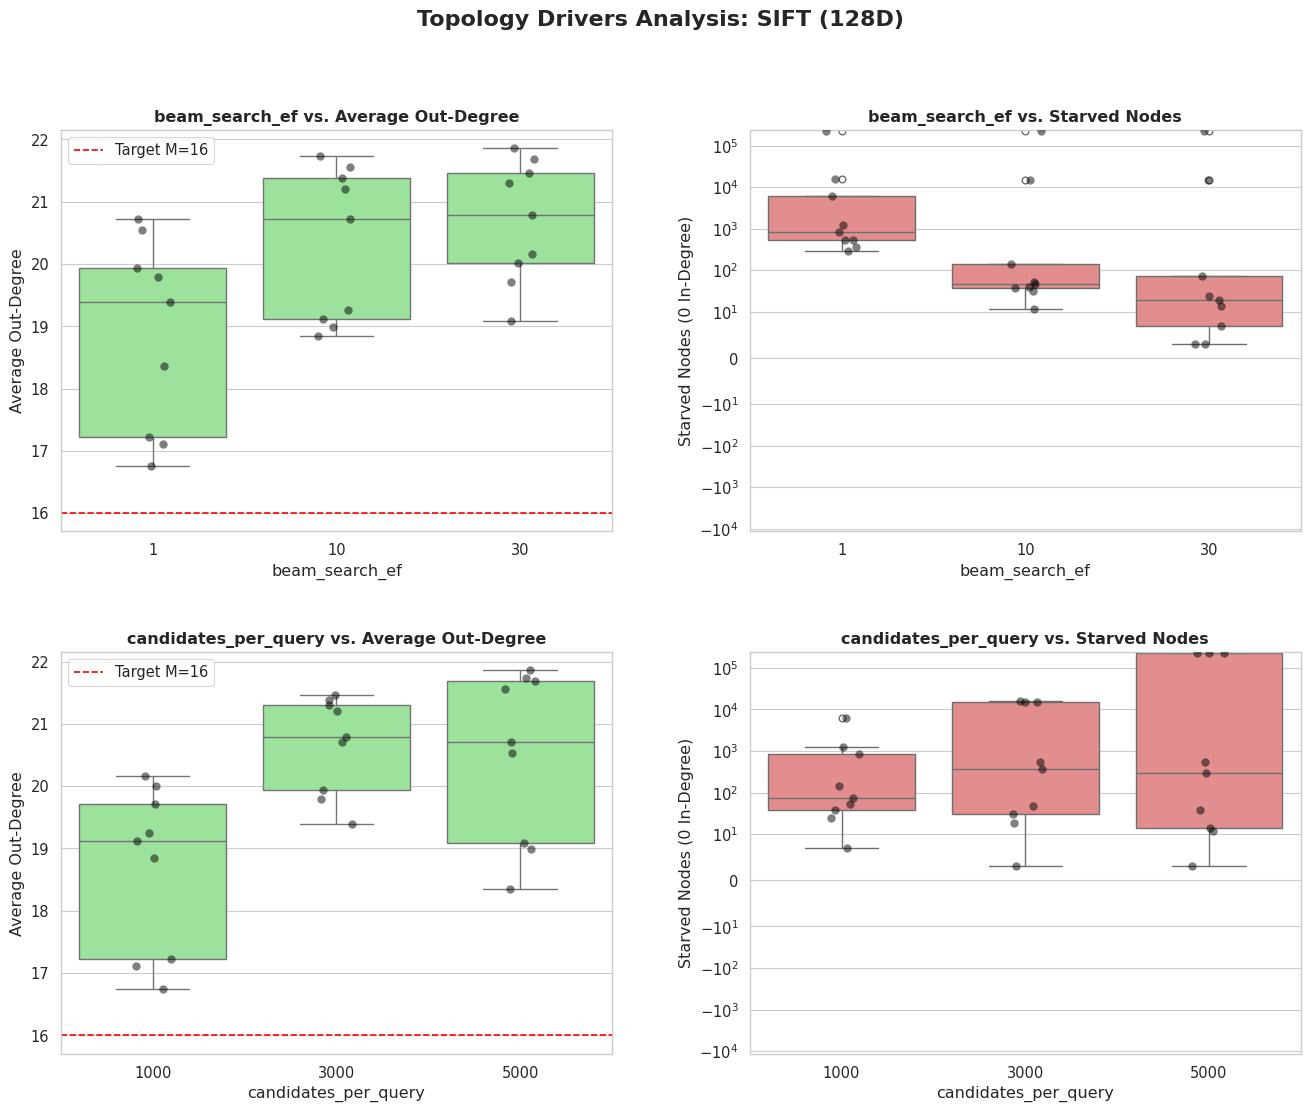

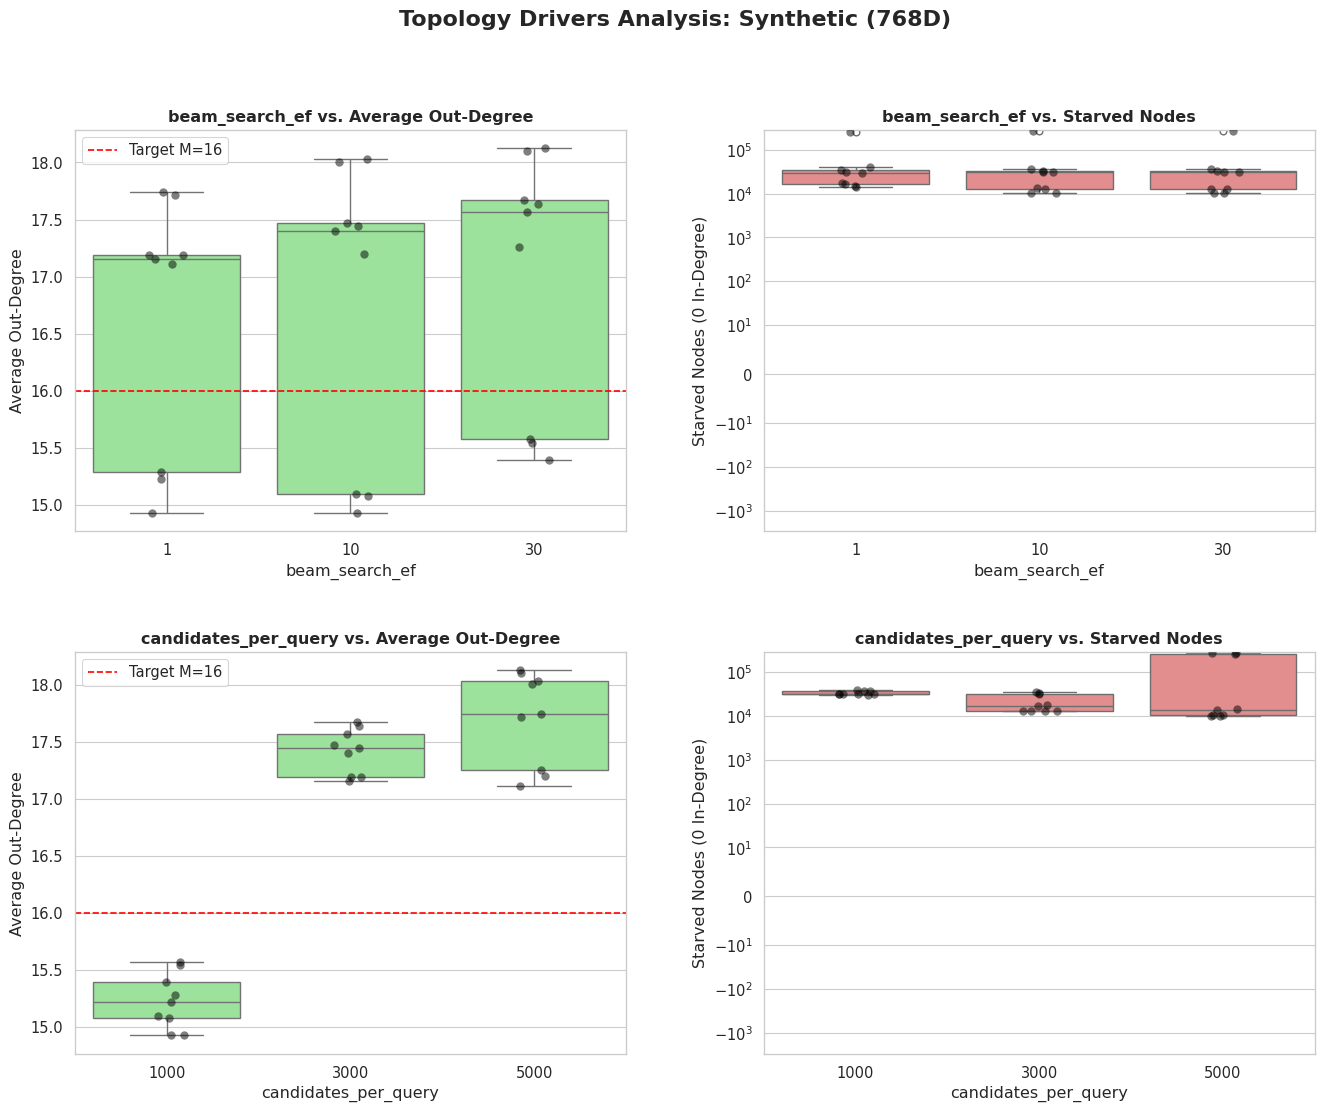

In [15]:
# --- FINAL PLOT: TOPOLOGY DRIVERS ANALYSIS (SIFT & 768D) ---
top_df = df[(df['type'] == 'Hybrid CPU-GPU') & (df['seed_size'] == 200000)].copy()

datasets = ['SIFT (128D)', 'Synthetic (768D)']

for ds_name in datasets:
    sub_df = top_df[top_df['dataset_clean'] == ds_name]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    plt.subplots_adjust(hspace=0.3, wspace=0.25)
    
    # ---------------------------------------------------------
    # ROW 1: beam_search_ef
    # ---------------------------------------------------------
    sns.boxplot(data=sub_df, x='beam_search_ef', y='avg_out_degree', color='lightgreen', ax=axes[0, 0])
    sns.stripplot(data=sub_df, x='beam_search_ef', y='avg_out_degree', color='black', alpha=0.5, size=6, ax=axes[0, 0])
    axes[0, 0].set_title('beam_search_ef vs. Average Out-Degree', fontweight='bold')
    axes[0, 0].set_xlabel('beam_search_ef')
    axes[0, 0].set_ylabel('Average Out-Degree')
    axes[0, 0].axhline(16, color='red', linestyle='--', label='Target M=16')
    axes[0, 0].legend()
    
    sns.boxplot(data=sub_df, x='beam_search_ef', y='starved_nodes', color='lightcoral', ax=axes[0, 1])
    sns.stripplot(data=sub_df, x='beam_search_ef', y='starved_nodes', color='black', alpha=0.5, size=6, ax=axes[0, 1])
    axes[0, 1].set_title('beam_search_ef vs. Starved Nodes', fontweight='bold')
    axes[0, 1].set_xlabel('beam_search_ef')
    axes[0, 1].set_ylabel('Starved Nodes (0 In-Degree)')
    axes[0, 1].set_yscale('symlog', linthresh=10)
    
    # ---------------------------------------------------------
    # ROW 2: candidates_per_query
    # ---------------------------------------------------------
    sns.boxplot(data=sub_df, x='candidates_per_query', y='avg_out_degree', color='lightgreen', ax=axes[1, 0])
    sns.stripplot(data=sub_df, x='candidates_per_query', y='avg_out_degree', color='black', alpha=0.5, size=6, ax=axes[1, 0])
    axes[1, 0].set_title('candidates_per_query vs. Average Out-Degree', fontweight='bold')
    axes[1, 0].set_xlabel('candidates_per_query')
    axes[1, 0].set_ylabel('Average Out-Degree')
    axes[1, 0].axhline(16, color='red', linestyle='--', label='Target M=16')
    axes[1, 0].legend()
    
    sns.boxplot(data=sub_df, x='candidates_per_query', y='starved_nodes', color='lightcoral', ax=axes[1, 1])
    sns.stripplot(data=sub_df, x='candidates_per_query', y='starved_nodes', color='black', alpha=0.5, size=6, ax=axes[1, 1])
    axes[1, 1].set_title('candidates_per_query vs. Starved Nodes', fontweight='bold')
    axes[1, 1].set_xlabel('candidates_per_query')
    axes[1, 1].set_ylabel('Starved Nodes (0 In-Degree)')
    axes[1, 1].set_yscale('symlog', linthresh=10)
    
    clean_title = ds_name.replace(" ", "_").replace("(", "").replace(")", "")
    plt.suptitle(f'Topology Drivers Analysis: {ds_name}', fontweight='bold', fontsize=16)
    plt.savefig(f'topology_drivers_{clean_title}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
# --- THE OPTIMAL CONFIGURATION EXTRACTOR ---
import pandas as pd

# Define acceptable recall limits based on your CPU baseline
# SIFT Baseline was ~0.98. Let's accept anything >= 0.95
# 768D Baseline was ~0.075. Let's accept anything >= 0.065

# BEST SIFT (128D) RUNS
sift_optimal = df[(df['dataset_clean'] == 'SIFT (128D)') & 
                  (df['type'] == 'Hybrid CPU-GPU') & 
                  (df['recall_10'] >= 0.95)].copy()

sift_optimal = sift_optimal.sort_values('throughput_vec_sec', ascending=False)

print("--- TOP 3 SIFT (128D) RUNS (Constraint: Recall >= 0.95) ---")
display(sift_optimal[['batch_size', 'candidates_per_query', 'beam_search_ef', 'seed_size', 'throughput_vec_sec', 'recall_10']].head(3))

print("\n")

# BEST SYNTHETIC (768D) RUNS
highdim_optimal = df[(df['dataset_clean'] == 'Synthetic (768D)') & 
                     (df['type'] == 'Hybrid CPU-GPU') & 
                     (df['recall_10'] >= 0.065)].copy()

highdim_optimal = highdim_optimal.sort_values('throughput_vec_sec', ascending=False)

print("--- TOP 3 SYNTHETIC (768D) RUNS (Constraint: Recall >= 0.065) ---")
display(highdim_optimal[['batch_size', 'candidates_per_query', 'beam_search_ef', 'seed_size', 'throughput_vec_sec', 'recall_10']].head(3))

 🏆 THE OPTIMAL CONFIGURATIONS FOR HARDWARE PROFILING 🏆 

--- TOP 3 SIFT (128D) RUNS (Constraint: Recall >= 0.95) ---


,batch_size,candidates_per_query,beam_search_ef,seed_size,throughput_vec_sec,recall_10
4,1000,1000,30,0,15098.1,0.961526
26,10000,3000,10,0,14496.4,0.954145
8,1000,3000,10,0,13359.2,0.966617




--- TOP 3 SYNTHETIC (768D) RUNS (Constraint: Recall >= 0.065) ---


,batch_size,candidates_per_query,beam_search_ef,seed_size,throughput_vec_sec,recall_10
84,10000,5000,1,0,2917.29,0.068800
66,1000,5000,1,0,2794.66,0.069380
86,10000,5000,10,0,2626.12,0.070539
